# This noteboook illustrates the solution of the model

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from Chorms import *

do_compile = False # should the c-functions be re-compiled?

import os
os.environ.pop('NoDefaultCurrentDirectoryInExePath', None)

do_reinstall_nlopt = True # If problems with NLOPT during re-compilation of c++ files, then try re-installing NLOPT by swithcing this to True and delete the folder "nlopt-2.4.2-dll64" in the cppfuncs folder before running this notebook.
if do_reinstall_nlopt:
    from LocalEconModel import cpptools
    cpptools.setup_nlopt(folder='cppfuncs/', do_print=False,download=False,unzip=True)

# Setup Model

In [2]:
model = ChormsClass() 
model.link_to_cpp(force_compile=do_compile)

In [3]:
# load/simulate data
model.load_data(do_simulate=True)

In [4]:
# try coarse grid search
model.par.do_gridsearch = True
%time model.solve()

CPU times: total: 31min 25s
Wall time: 1min 39s


In [5]:
model_num = ChormsClass(par={'do_gridsearch':False,'reuse_init':False})
model_num.link_to_cpp(force_compile=False)
model_num.load_data(do_simulate=True)

In [6]:
%time model_num.solve()

CPU times: total: 42.2 s
Wall time: 2.36 s


In [7]:
model_reuse = ChormsClass(par={'do_gridsearch':False,'reuse_init':True})
model_reuse.link_to_cpp(force_compile=False)
model_reuse.load_data(do_simulate=True)

%time model_reuse.solve()

CPU times: total: 14.2 s
Wall time: 838 ms


In [8]:
print(model_num.sol.home_w[0:10])
model_num.sol.home_share_exp_w

[1.7630257  0.64019757 0.84621062 0.69765352 0.48636478 2.15798217
 1.87235032 2.27365383 0.55835432 1.2487809 ]


array([nan, nan, nan, ..., nan, nan, nan], shape=(5000,))

In [9]:
%time model_num.solve(do_exp=True)
print(model_num.sol.home_w[0:10])
model_num.sol.home_share_exp_w

CPU times: total: 1min 16s
Wall time: 4.7 s
[1.7630257  0.64019757 0.84621062 0.69765352 0.48636478 2.15798217
 1.87235032 2.27365383 0.55835432 1.2487809 ]


array([0.86922624, 0.3586748 , 0.37849102, ..., 0.85081822, 0.18521557,
       0.79154229], shape=(5000,))

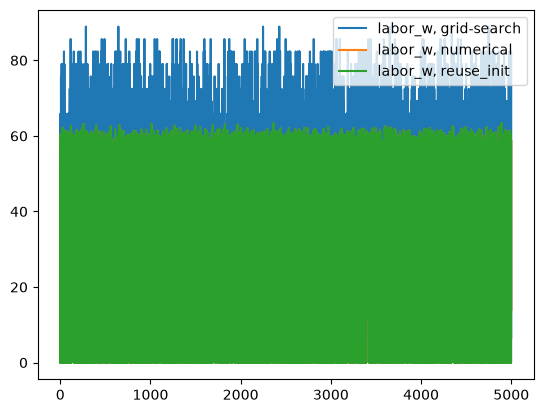

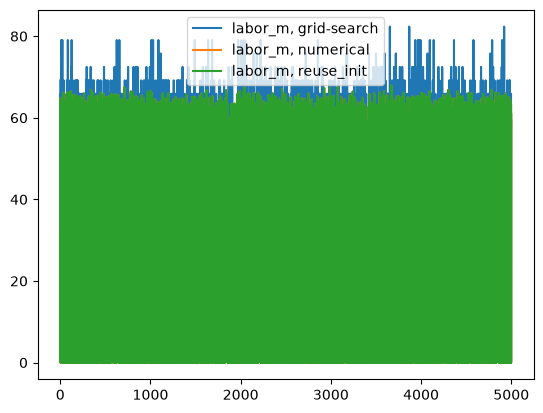

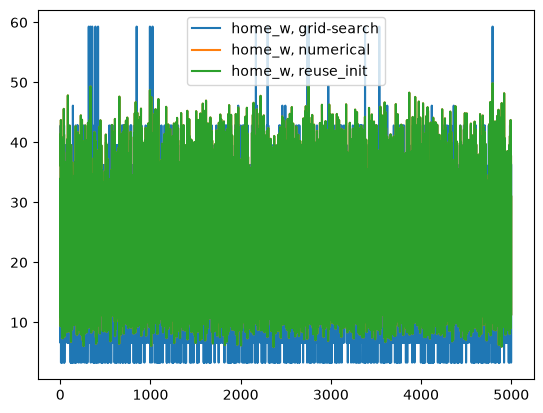

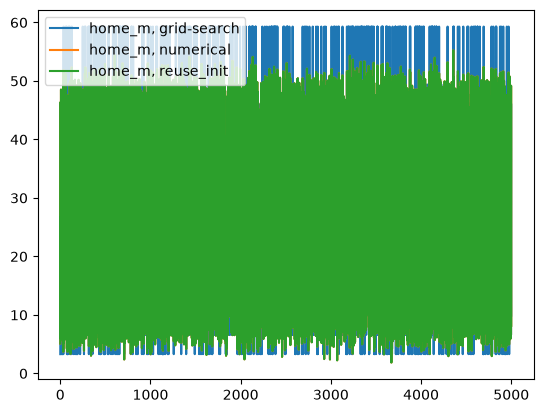

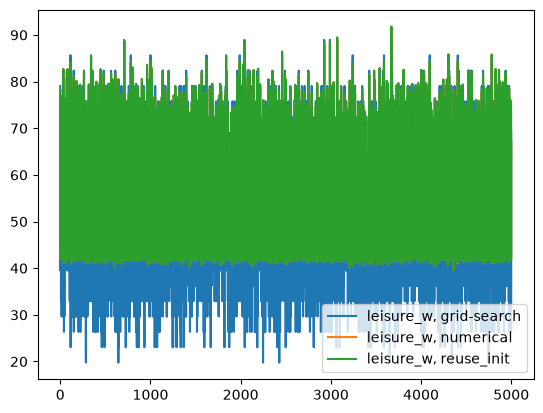

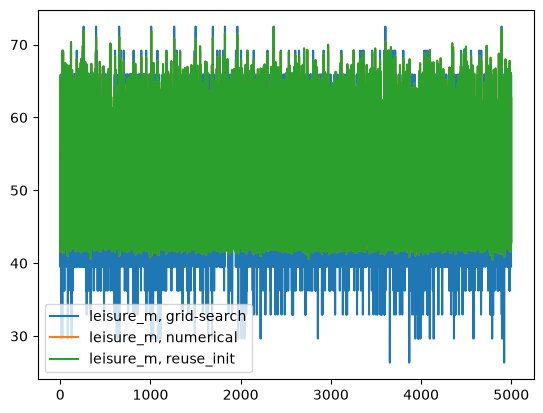

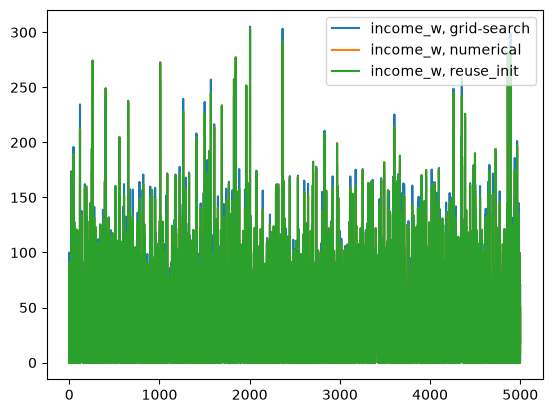

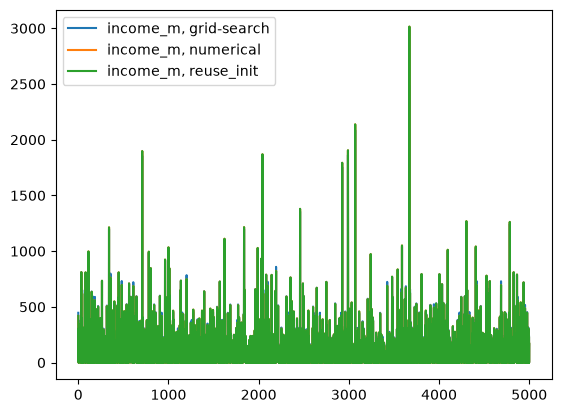

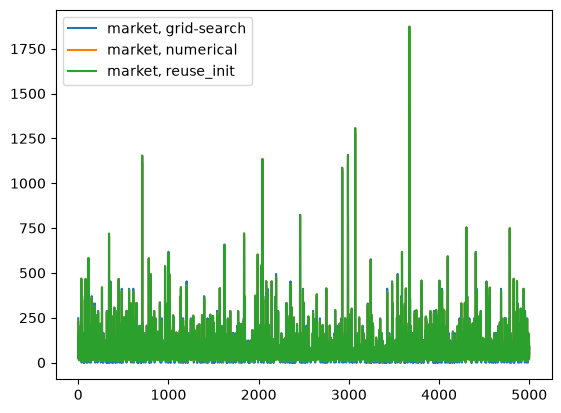

In [10]:
y2w = 1000 / 52 # year to week conversion factor
u2d = 7 # usd to dkk

# compare solution approaches
linestyle='solid'
fig,ax = plt.subplots()
ax.plot(model.sol.labor_w * y2w, label='labor_w, grid-search')
ax.plot(model_num.sol.labor_w * y2w, label='labor_w, numerical')
ax.plot(model_reuse.sol.labor_w * y2w, label='labor_w, reuse_init',linestyle=linestyle)
ax.legend();

fig,ax = plt.subplots()
ax.plot(model.sol.labor_m * y2w, label='labor_m, grid-search')
ax.plot(model_num.sol.labor_m * y2w, label='labor_m, numerical')
ax.plot(model_reuse.sol.labor_m * y2w, label='labor_m, reuse_init',linestyle=linestyle)
ax.legend();

fig,ax = plt.subplots()
ax.plot(model.sol.home_w * y2w, label='home_w, grid-search')
ax.plot(model_num.sol.home_w * y2w, label='home_w, numerical')
ax.plot(model_reuse.sol.home_w * y2w, label='home_w, reuse_init',linestyle=linestyle)
ax.legend();

fig,ax = plt.subplots()
ax.plot(model.sol.home_m * y2w, label='home_m, grid-search')
ax.plot(model_num.sol.home_m * y2w, label='home_m, numerical')
ax.plot(model_reuse.sol.home_m * y2w, label='home_m, reuse_init',linestyle=linestyle)
ax.legend();

fig,ax = plt.subplots()
ax.plot((model.par.total_time - model.sol.labor_w - model.sol.home_w) * y2w, label='leisure_w, grid-search')
ax.plot((model_num.par.total_time - model_num.sol.labor_w - model_num.sol.home_w) * y2w, label='leisure_w, numerical')
ax.plot((model_reuse.par.total_time - model_reuse.sol.labor_w - model_reuse.sol.home_w) * y2w, label='leisure_w, reuse_init',linestyle=linestyle)
ax.legend();

fig,ax = plt.subplots()
ax.plot((model.par.total_time - model.sol.labor_m - model.sol.home_m) * y2w, label='leisure_m, grid-search')
ax.plot((model_num.par.total_time - model_num.sol.labor_m - model_num.sol.home_m) * y2w, label='leisure_m, numerical')
ax.plot((model_reuse.par.total_time - model_reuse.sol.labor_m - model_reuse.sol.home_m) * y2w, label='leisure_m, reuse_init',linestyle=linestyle)
ax.legend();

fig,ax = plt.subplots()
ax.plot(model.sol.labor_w * model.sim.wage_w * u2d, label='income_w, grid-search')
ax.plot(model_num.sol.labor_w * model_num.sim.wage_w * u2d, label='income_w, numerical')
ax.plot(model_reuse.sol.labor_w * model_reuse.sim.wage_w * u2d, label='income_w, reuse_init',linestyle=linestyle)
ax.legend();

fig,ax = plt.subplots()
ax.plot(model.sol.labor_m * model.sim.wage_m * u2d, label='income_m, grid-search')
ax.plot(model_num.sol.labor_m * model_num.sim.wage_m * u2d, label='income_m, numerical')
ax.plot(model_reuse.sol.labor_m * model_reuse.sim.wage_m * u2d, label='income_m, reuse_init',linestyle=linestyle)
ax.legend();

fig,ax = plt.subplots()
ax.plot(model.sol.market * u2d, label='market, grid-search')
ax.plot(model_num.sol.market * u2d, label='market, numerical')
ax.plot(model_reuse.sol.market * u2d, label='market, reuse_init',linestyle=linestyle)
ax.legend();

## Test estimator

In [11]:
# test
theta_names = ['util_public','util_leisure_w']
init = np.array([model.par.util_public*0.9,model.par.util_leisure_w*0.9])

%time obj(theta=init,theta_names=theta_names,model=model_num,do_gridsearch=False,do_print=True);

util_public=1.350 util_leisure_w=3.600 ->obj: 0.3339
CPU times: total: 1min 33s
Wall time: 4.87 s


In [12]:
se = standard_errors(init,theta_names,model,data_outcomes=None,weight=None,var_list=None,do_gridsearch=False)
print(se)
# [1.03621582e-05 1.68846750e-05]

[3.15858658e-05 4.23171996e-05]


In [13]:
from scipy.optimize import minimize
# theta_names = ['util_public',]
# init = np.array([model.par.util_public])


model = ChormsClass(par={'do_gridsearch':False,'reuse_init':True})
model.link_to_cpp(force_compile=False)
model.load_data(do_simulate=True)


theta_names = ['util_public','util_leisure_w']
init = np.array([model.par.util_public*0.9,model.par.util_leisure_w*0.9])

do_gridsearch = False
data_outcomes = np.column_stack([getattr(model.sim,var) for var in ['labor_w','labor_m','home_w','home_m','market','home_share_exp_w']])

obj_func = lambda theta: obj(theta,theta_names,model,data_outcomes=data_outcomes,weight=None,var_list=None,do_gridsearch=False,do_print=True)

res = minimize(obj_func,init,method='Nelder-Mead',options={'maxiter':1000})



util_public=1.350 util_leisure_w=3.600 ->obj: 0.3337
util_public=1.418 util_leisure_w=3.600 ->obj: 0.1410
util_public=1.350 util_leisure_w=3.780 ->obj: 0.3463
util_public=1.417 util_leisure_w=3.420 ->obj: 0.1596
util_public=1.485 util_leisure_w=3.420 ->obj: 0.1247
util_public=1.552 util_leisure_w=3.330 ->obj: 0.2434
util_public=1.485 util_leisure_w=3.600 ->obj: 0.0888
util_public=1.519 util_leisure_w=3.690 ->obj: 0.0918
util_public=1.552 util_leisure_w=3.420 ->obj: 0.2104
util_public=1.451 util_leisure_w=3.555 ->obj: 0.1043
util_public=1.451 util_leisure_w=3.735 ->obj: 0.0876
util_public=1.434 util_leisure_w=3.892 ->obj: 0.1069
util_public=1.485 util_leisure_w=3.780 ->obj: 0.0670
util_public=1.502 util_leisure_w=3.892 ->obj: 0.0591
util_public=1.468 util_leisure_w=4.027 ->obj: 0.0703
util_public=1.519 util_leisure_w=4.185 ->obj: 0.0640
util_public=1.553 util_leisure_w=4.050 ->obj: 0.0867
util_public=1.489 util_leisure_w=4.033 ->obj: 0.0577
util_public=1.472 util_leisure_w=3.741 ->obj: 

In [14]:
# test log-lik
# model.par.util_public = 0.9
loglik_vec = np.nan + np.ones(model.par.num_N)
model.cpp.LogLik(loglik_vec,model.sol,model.sim,model.par)

loglik_vec[0:20]

# array([-5.51363127, -5.5136312 , -5.5136312 , -5.5136312 , -5.5136312 ,
#        -5.5136312 , -5.51363126, -5.5136312 , -5.51363121, -5.51363121])

array([-0.9518593 ,  0.50166643,  4.47364821, -0.04411935,  4.24655679,
        3.09661149,  1.42449834,  2.03504747,  3.26647297,  0.61103877,
        2.30537848,  3.7294778 ,  1.36186996,  1.24974237, -0.33949662,
        3.19528929,  3.43607339,  1.88952714,  1.94882601,  1.43679436])

In [15]:
model.par.wage_cov

np.float64(0.12414632594785238)

In [16]:
%time obj_loglik(init,theta_names,model,do_print=True)

util_public=1.350 util_leisure_w=3.600 ->obj: 0.6170
CPU times: total: 30.8 s
Wall time: 2.35 s


np.float64(0.6170479058258895)

In [17]:
loglik_vec = np.nan + np.ones(model.par.num_N)
model.cpp.LogLik(loglik_vec, model.sol, model.sim, model.par)

In [18]:
loglik_vec

array([-6.22020405, -0.88555032,  3.00671731, ..., -3.32610491,
        2.00745086, -2.54108723], shape=(5000,))